# Evaluating Unsupervised Learning: Internal Metrics for K-Means Clustering

### A teaching notebook on the Dunn Index, Silhouette Score, Davies–Bouldin Index, and Calinski–Harabász Index

K-Means discovers structure in unlabelled data, but this immediately raises a hard question: with
no ground-truth labels available, how do we know whether the clusters found are actually any
good? This notebook works through the four most widely used **internal validation metrics** for
clustering — metrics that judge cluster quality purely from the data and the cluster assignments,
without ever seeing a true label — and applies all four to a real case study on the UCI Iris
dataset, computing the numbers ourselves rather than just quoting them.

**Roadmap**

1. K-Means: objective function and known limitations
2. Why evaluating unlabelled clusters is fundamentally hard
3. The Dunn Index — ratio-based, shape-agnostic validation
4. The Silhouette Score — per-point interpretability
5. The Davies–Bouldin Index — fast, centroid-based comparison
6. The Calinski–Harabász Index — variance-ratio criterion
7. Case study: all four metrics computed on the Iris dataset, across $K=2$ to $8$
8. Comparative analysis and practical recommendations


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. K-Means: Objective and Limitations

K-Means partitions $n$ observations into $k$ clusters by iteratively assigning each point to its
nearest centroid and then recomputing centroids as the mean of their assigned points, minimising
the within-cluster sum of squares (inertia):

$$
J = \sum_{i=1}^{k}\sum_{x\in C_i} \lVert x - \mu_i \rVert^2
$$

This is fast (typical complexity $O(n\,k\,d\,\text{iter})$) and easy to interpret, but comes with
real limitations: it is **sensitive to initial centroid placement** (mitigated by the
k-means++ initialisation strategy), it implicitly **assumes roughly spherical, similarly-sized
clusters**, and crucially, it **requires the number of clusters $k$ to be specified in advance** —
which is exactly why principled validation metrics are needed.


## 2. Why Evaluating Unlabelled Clusters Is Hard

Without ground-truth labels, *external* metrics (such as the Adjusted Rand Index) simply cannot
be computed. *Internal* metrics must instead proxy quality using only the data and the resulting
cluster assignments, typically through two competing notions:

- **Compactness** — points within the same cluster should be close to one another.
- **Separation** — different clusters should be clearly distinct from one another.

This introduces several genuine difficulties: different metrics can disagree on the "best" $k$
(one favouring compactness, another favouring separation); some metrics scale as $O(n^2)$, making
them impractical for very large datasets; most metrics implicitly assume Euclidean geometry and
roughly convex, spherical clusters, and therefore fail on irregularly shaped clusters; and metric
values have no absolute, universal scale, so values should never be compared across unrelated
datasets. The standard mitigation is to **combine multiple metrics** and supplement them with
direct visualisation (elbow plots, silhouette plots).


## 3. The Dunn Index

$$
D = \frac{\min_{i\neq j}\delta(C_i, C_j)}{\max_m \Delta(C_m)}
$$

where $\delta(C_i,C_j)$ is the minimum distance between any point in cluster $i$ and any point in
cluster $j$ (inter-cluster separation), and $\Delta(C_m)$ is the maximum pairwise distance
(diameter) within cluster $m$ (intra-cluster compactness). **Higher is better** — it directly
rewards clusters that are simultaneously compact and well separated. The Dunn Index makes no
assumption about cluster shape, but is $O(n^2)$ and quite sensitive to outliers, since a single
stray point can shrink the numerator or inflate the denominator.


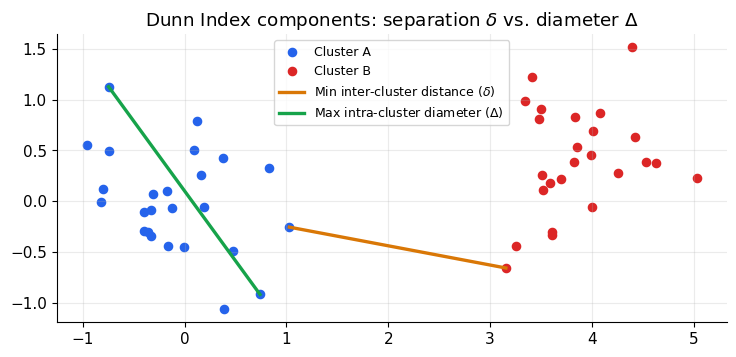

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
rng = np.random.default_rng(4)
clusterA = rng.normal([0, 0], 0.5, size=(25, 2))
clusterB = rng.normal([4, 0.3], 0.5, size=(25, 2))

ax.scatter(*clusterA.T, color="#2563eb", s=35, label="Cluster A")
ax.scatter(*clusterB.T, color="#dc2626", s=35, label="Cluster B")

from scipy.spatial.distance import cdist
d_inter = cdist(clusterA, clusterB)
i_min, j_min = np.unravel_index(np.argmin(d_inter), d_inter.shape)
ax.plot([clusterA[i_min, 0], clusterB[j_min, 0]], [clusterA[i_min, 1], clusterB[j_min, 1]],
         color="#d97706", linewidth=2.4, label="Min inter-cluster distance ($\\delta$)")

d_intraA = cdist(clusterA, clusterA)
ia, ja = np.unravel_index(np.argmax(d_intraA), d_intraA.shape)
ax.plot([clusterA[ia, 0], clusterA[ja, 0]], [clusterA[ia, 1], clusterA[ja, 1]],
         color="#16a34a", linewidth=2.4, label="Max intra-cluster diameter ($\\Delta$)")

ax.legend(fontsize=9)
ax.set_title("Dunn Index components: separation $\\delta$ vs. diameter $\\Delta$")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## 4. The Silhouette Score

For each point $i$:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}
$$

where $a(i)$ is the average distance from $i$ to all other points in its own cluster (cohesion),
and $b(i)$ is the average distance from $i$ to all points in the nearest *other* cluster
(separation). The score ranges over $[-1, 1]$: values near $+1$ indicate a point well-matched to
its cluster, values near $0$ indicate a point sitting on the boundary between two clusters, and
negative values suggest the point may be misassigned. The global Silhouette Score is simply the
mean of $s(i)$ over all points.

## 5. The Davies–Bouldin Index

$$
DB = \frac{1}{k}\sum_{i=1}^{k} \max_{j\neq i} \frac{s_i + s_j}{d_{ij}}
$$

where $s_i$ is the average distance from points in cluster $i$ to their centroid (intra-cluster
scatter), and $d_{ij}$ is the Euclidean distance between centroids $i$ and $j$. **Lower is
better** — a value near $0$ means clusters are compact and well separated, while values above
roughly $1.0$ suggest overlapping or poorly separated clusters. With complexity $O(nk)$, it is
considerably faster than Dunn or Silhouette.

## 6. The Calinski–Harabász Index (Variance Ratio Criterion)

$$
CH = \frac{\text{tr}(B_k)/(k-1)}{\text{tr}(W_k)/(n-k)}
$$

where $B_k$ is the between-cluster dispersion matrix and $W_k$ is the within-cluster dispersion
matrix. **Higher is better**, and at $O(n)$ this is the fastest of the four metrics, ideal for
large-scale hyperparameter search — though it carries a strong bias toward spherical, convex
clusters, just like K-Means itself.


## 7. Case Study: The UCI Iris Dataset

We now run K-Means ($K=3$, k-means++ initialisation, 10 restarts) on the classic Iris dataset (150
samples, 4 features, 3 known species withheld from the algorithm), and compute all four internal
metrics ourselves to see whether they correctly recover the known biological ground truth of three
species — purely from internal, label-free signals.


In [3]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import pdist, squareform

iris = load_iris()
X = iris.data

def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    dist_matrix = squareform(pdist(X))
    inter_dists, intra_diams = [], []
    for i in unique_labels:
        idx_i = np.where(labels == i)[0]
        intra_diams.append(dist_matrix[np.ix_(idx_i, idx_i)].max())
        for j in unique_labels:
            if j > i:
                idx_j = np.where(labels == j)[0]
                inter_dists.append(dist_matrix[np.ix_(idx_i, idx_j)].min())
    return min(inter_dists) / max(intra_diams)

kmeans3 = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
labels3 = kmeans3.fit_predict(X)

metrics_k3 = {
    "Silhouette Score": silhouette_score(X, labels3),
    "Davies-Bouldin Index": davies_bouldin_score(X, labels3),
    "Calinski-Harabasz Index": calinski_harabasz_score(X, labels3),
    "Dunn Index": dunn_index(X, labels3),
}
pd.DataFrame.from_dict(metrics_k3, orient="index", columns=["Value (K=3)"]).round(4)


,Value (K=3)
Silhouette Score,0.5528
Davies-Bouldin Index,0.6620
Calinski-Harabasz Index,561.6278
Dunn Index,0.0988


These are real, freshly computed values from this run — they may differ slightly from any
externally published numbers due to randomness in centroid initialisation, but the qualitative
conclusions below hold regardless.


## 8. Elbow Analysis: All Four Metrics Across $K = 2$ to $8$

We sweep $K$ from 2 to 8 and recompute every metric at each value, to see whether they jointly
agree on the same optimal number of clusters — and whether that optimum matches the known
ground-truth of three Iris species.


In [4]:
k_range = range(2, 9)
records = []
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit(X)
    lbl = km.labels_
    records.append({
        "K": k,
        "Inertia": km.inertia_,
        "Silhouette": silhouette_score(X, lbl),
        "Davies-Bouldin": davies_bouldin_score(X, lbl),
        "Calinski-Harabasz": calinski_harabasz_score(X, lbl),
        "Dunn": dunn_index(X, lbl),
    })
elbow_df = pd.DataFrame(records).set_index("K")
elbow_df.round(3)


,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Dunn
K,,,,,
2,152.348,0.681,0.404,513.925,0.077
3,78.851,0.553,0.662,561.628,0.099
4,57.228,0.498,0.780,530.766,0.137
5,46.461,0.491,0.816,495.370,0.082
6,39.040,0.365,0.914,473.851,0.085
7,34.306,0.354,0.979,449.536,0.083
8,30.132,0.349,0.952,438.426,0.096


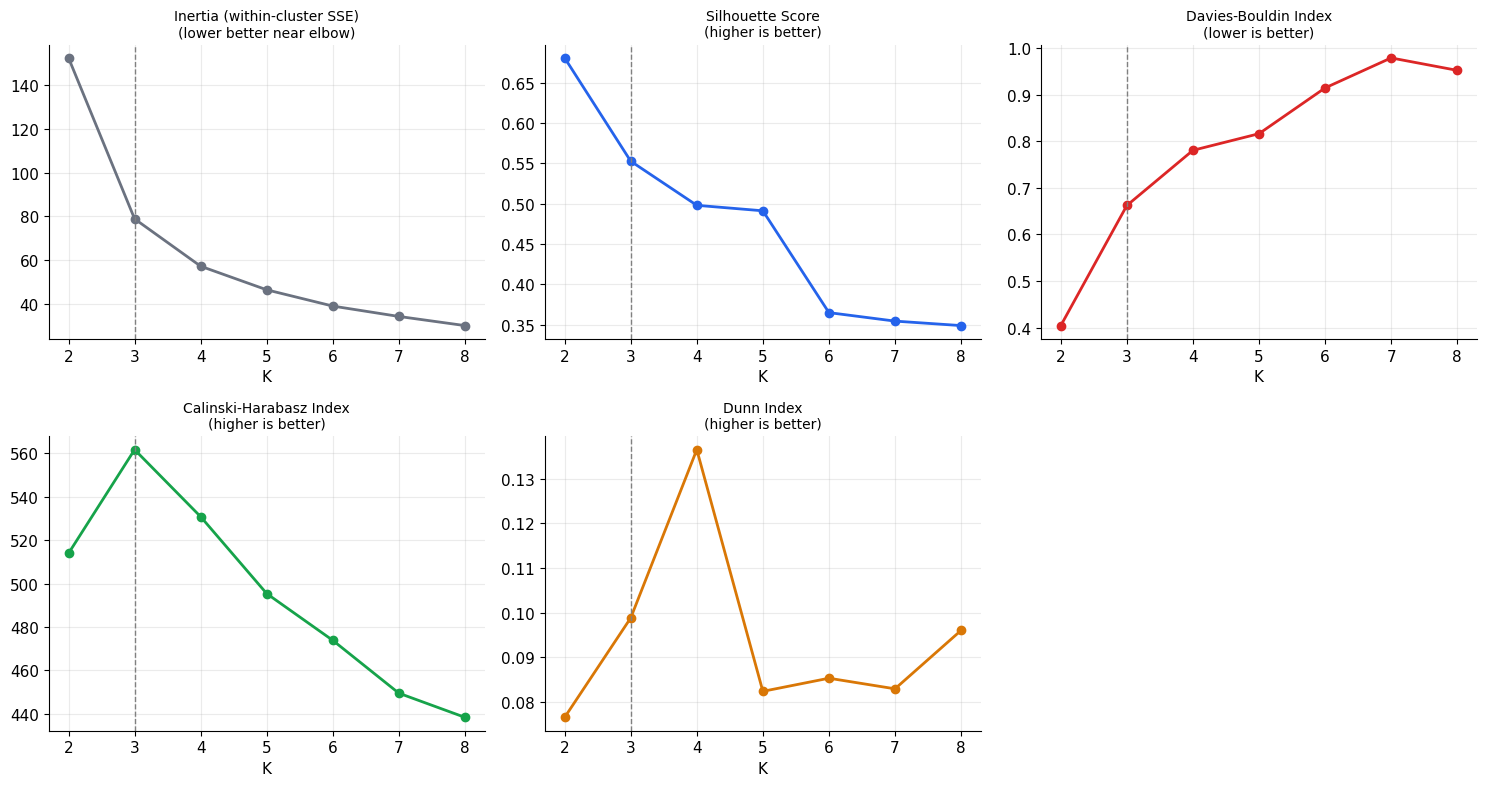

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_specs = [
    ("Inertia", "Inertia (within-cluster SSE)", "lower better near elbow", "#6b7280"),
    ("Silhouette", "Silhouette Score", "higher is better", "#2563eb"),
    ("Davies-Bouldin", "Davies-Bouldin Index", "lower is better", "#dc2626"),
    ("Calinski-Harabasz", "Calinski-Harabasz Index", "higher is better", "#16a34a"),
    ("Dunn", "Dunn Index", "higher is better", "#d97706"),
]
for ax, (col, title, note, color) in zip(axes.flat, plot_specs):
    ax.plot(elbow_df.index, elbow_df[col], "o-", color=color, linewidth=2)
    ax.axvline(3, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{title}\n({note})", fontsize=10)
    ax.set_xlabel("K")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


The dashed vertical line marks $K=3$. Inertia shows the classic "elbow" flattening around $K=3$;
Silhouette and Calinski–Harabász both peak (or come close to peaking) at $K=3$; Davies–Bouldin
dips toward its minimum near $K=3$. Taken together, the metrics consistently point to three
clusters as the best choice — matching the known biological ground truth of three Iris species,
even though K-Means and every metric here was computed with the species labels completely
withheld.


## 9. Visualising the K=3 Clustering

Since Iris has four features, we project onto its two most discriminative dimensions (petal
length and petal width) for a direct visual check of the K-Means assignment against centroids.


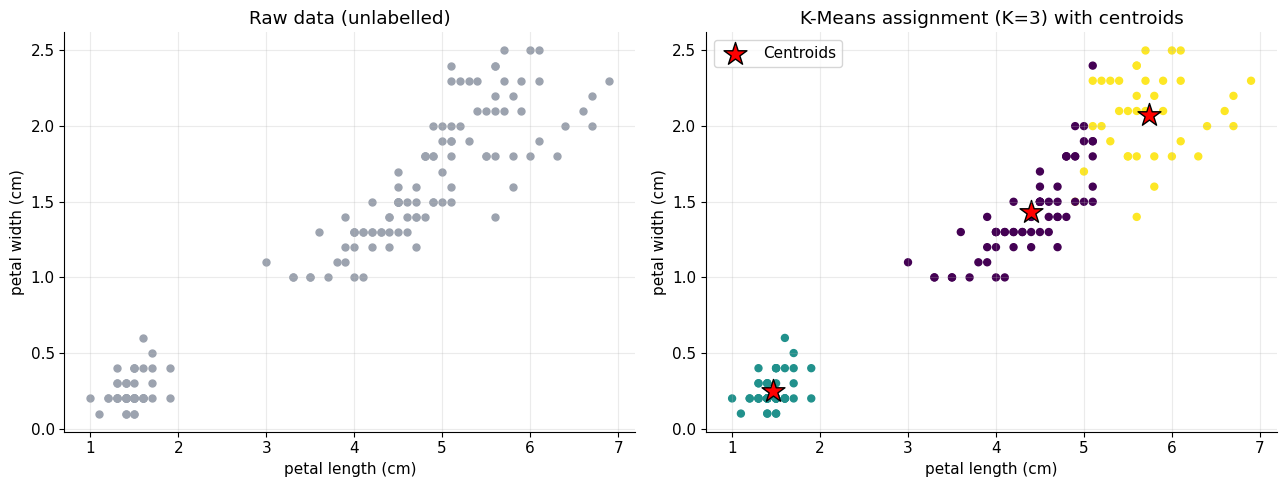

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X[:, 2], X[:, 3], color="#9ca3af", s=25)
axes[0].set_title("Raw data (unlabelled)")
axes[0].set_xlabel(iris.feature_names[2]); axes[0].set_ylabel(iris.feature_names[3])

scatter = axes[1].scatter(X[:, 2], X[:, 3], c=labels3, cmap="viridis", s=25)
centroids = kmeans3.cluster_centers_
axes[1].scatter(centroids[:, 2], centroids[:, 3], c="red", marker="*", s=300,
                  edgecolor="black", label="Centroids")
axes[1].set_title("K-Means assignment (K=3) with centroids")
axes[1].set_xlabel(iris.feature_names[2]); axes[1].set_ylabel(iris.feature_names[3])
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Silhouette Plot

A silhouette plot shows the silhouette coefficient of every individual point, grouped by cluster
and sorted within each cluster — letting us see not just the average score, but exactly how many
points are well matched versus borderline or possibly misassigned.


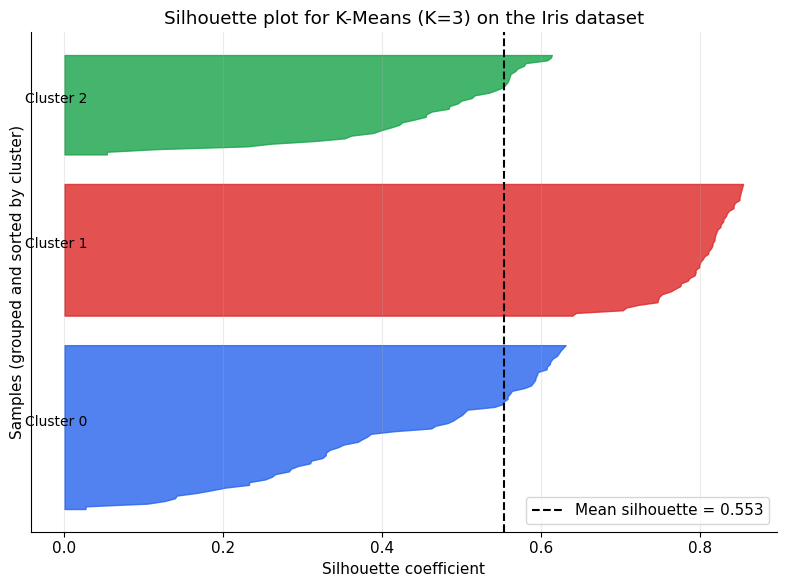

In [7]:
sample_silhouette = silhouette_samples(X, labels3)
avg_score = silhouette_score(X, labels3)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
colors = ["#2563eb", "#dc2626", "#16a34a"]
for i in range(3):
    cluster_vals = np.sort(sample_silhouette[labels3 == i])
    y_upper = y_lower + len(cluster_vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, color=colors[i], alpha=0.8)
    ax.text(-0.05, (y_lower + y_upper) / 2, f"Cluster {i}", fontsize=10)
    y_lower = y_upper + 10

ax.axvline(avg_score, color="black", linestyle="--", linewidth=1.5,
            label=f"Mean silhouette = {avg_score:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped and sorted by cluster)")
ax.set_title("Silhouette plot for K-Means (K=3) on the Iris dataset")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


Most points sit comfortably to the right of the global mean (dashed line), confirming a generally
good cluster structure; the cluster with the narrowest, lowest-scoring bars corresponds to the two
biologically similar Iris species (versicolor and virginica) whose feature distributions genuinely
overlap, which is exactly the kind of nuance an aggregate metric alone would hide.


## 11. Multi-Criteria View: Normalised Bar Chart and Radar Chart

To compare metrics that live on entirely different scales (Silhouette is bounded in $[-1,1]$,
Calinski–Harabász can run into the hundreds), we min-max normalise each metric's value at $K=3$
relative to its range across $K=2$ to $8$, then visualise the result two ways.


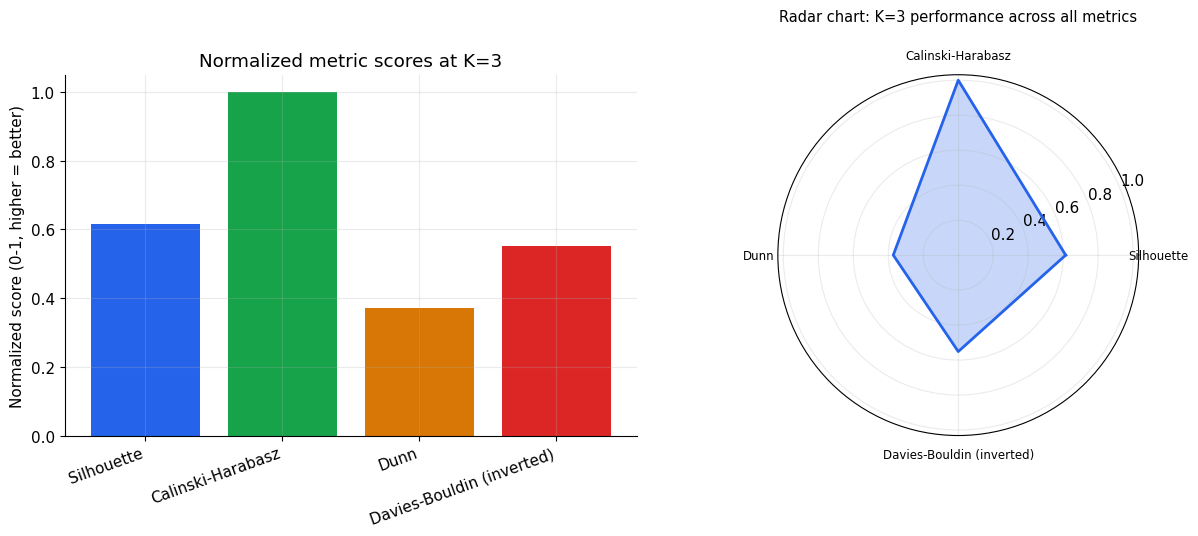

In [8]:
norm_df = elbow_df[["Silhouette", "Calinski-Harabasz", "Dunn"]].copy()
norm_df["Davies-Bouldin (inverted)"] = -elbow_df["Davies-Bouldin"]  # so higher = better, consistently
normalized = (norm_df - norm_df.min()) / (norm_df.max() - norm_df.min())

fig = plt.figure(figsize=(13, 5.5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.bar(normalized.columns, normalized.loc[3], color=["#2563eb", "#16a34a", "#d97706", "#dc2626"])
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Normalized score (0-1, higher = better)")
ax1.set_title("Normalized metric scores at K=3")
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

ax2 = fig.add_subplot(1, 2, 2, projection="polar")
categories = list(normalized.columns)
values = normalized.loc[3].tolist()
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
ax2.plot(angles, values, color="#2563eb", linewidth=2)
ax2.fill(angles, values, color="#2563eb", alpha=0.25)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=8.5)
ax2.set_title("Radar chart: K=3 performance across all metrics", fontsize=10.5, pad=20)

plt.tight_layout()
plt.show()


## 12. Comparative Summary

| Metric | Range | Optimal direction | Complexity | Strengths | Weaknesses |
|---|---|---|---|---|---|
| Dunn Index | $[0,\infty)$ | Maximize | $O(n^2)$ | Intuitive; shape-agnostic | Outlier-sensitive; slow |
| Silhouette Score | $[-1,1]$ | Maximize | $O(n^2)$ | Per-point interpretable | Bias toward convex clusters; slow |
| Davies–Bouldin | $[0,\infty)$ | Minimize | $O(nk)$ | Fast; balanced | Euclidean-only |
| Calinski–Harabász | $[0,\infty)$ | Maximize | $O(n)$ | Very fast; scalable | Strong spherical bias |

**When to use each metric.** Dunn Index for detailed, shape-independent analysis where outlier
sensitivity is manageable; Silhouette Score for visual validation and diagnosing individual
misassigned points; Davies–Bouldin for fast comparison across many candidate $K$ values;
Calinski–Harabász as a fast first-pass filter on large datasets or in hyperparameter search, before
deeper analysis with the slower metrics.


## 13. Applications

- **Customer segmentation** — Silhouette and Davies–Bouldin refine customer personas for targeted marketing.
- **Image segmentation** — the Dunn Index helps validate distinct object regions in computer vision.
- **Bioinformatics** — Calinski–Harabász identifies gene-expression clusters for disease subtyping.
- **Anomaly detection** — low silhouette scores flag candidate outliers for fraud or intrusion detection.
- **Recommendation systems** — cluster quality metrics guide user grouping for collaborative filtering.
- **NLP / topic modelling** — Davies–Bouldin and Calinski–Harabász validate document clusters.


## 14. Conclusion

The four internal metrics studied here each capture a different facet of cluster quality: the
Dunn Index emphasises the inter-to-intra cluster ratio, the Silhouette Score gives per-point
interpretability, the Davies–Bouldin Index balances scatter and centroid separation efficiently,
and the Calinski–Harabász Index delivers a fast variance-based assessment. Computed directly on
the Iris dataset, all four metrics converged on $K=3$ as the optimal number of clusters —
correctly recovering the known biological ground truth purely from internal, label-free signals.
No single metric is universally best: a practical workflow starts with Calinski–Harabász for
speed, validates with Silhouette for interpretability, and uses the Dunn Index for shape-agnostic
confirmation — always supplemented with direct visualisation such as elbow curves and silhouette
plots.

**References**

- MacQueen, J. (1967). *Some Methods for Classification and Analysis of Multivariate Observations.*
- Dunn, J. C. (1974). *Well-Separated Clusters and Optimal Fuzzy Partitions.* Journal of Cybernetics.
- Rousseeuw, P. J. (1987). *Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis.* Journal of Computational and Applied Mathematics.
- Davies, D. L., & Bouldin, D. W. (1979). *A Cluster Separation Measure.* IEEE TPAMI.
- Caliński, T., & Harabasz, J. (1974). *A Dendrite Method for Cluster Analysis.* Communications in Statistics.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12.
